In [5]:
!pip install -q grad-cam

In [6]:
# ── KAGGLE CONFIG ──
import os
import torch

DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-5
WEIGHT_DECAY= 1e-4
SEED        = 42
NUM_WORKERS = 2
PATIENCE    = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

import torch, numpy as np
torch.manual_seed(SEED)
np.random.seed(SEED)
print("✅ Config ready")

Device: cuda
GPU: Tesla T4
✅ Config ready


In [7]:
import cv2, numpy as np, os, torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms

# Official BRISC split — NO CLAHE
TRAIN_DIR = os.path.join(DATA_ROOT, "classification_task", "train")
TEST_DIR  = os.path.join(DATA_ROOT, "classification_task", "test")

# ── TRANSFORMS ──
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

inference_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── LOAD DATASETS ──
full_train_dataset = datasets.ImageFolder(TRAIN_DIR)
test_dataset_raw   = datasets.ImageFolder(TEST_DIR)

class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes  :", class_names)
print("Train+Val:", len(full_train_dataset))
print("Test     :", len(test_dataset_raw))

targets = [s[1] for s in full_train_dataset.samples]

train_idx, val_idx = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.20,
    stratify=targets,
    random_state=SEED
)

print(f"Split — Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_dataset_raw)}")

class CustomImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_samples = [full_train_dataset.samples[i] for i in train_idx]
val_samples   = [full_train_dataset.samples[i] for i in val_idx]

train_dataset = CustomImageDataset(train_samples, transform=train_tfms)
val_dataset   = CustomImageDataset(val_samples,   transform=inference_tfms)
test_dataset  = CustomImageDataset(test_dataset_raw.samples, transform=inference_tfms)

# ── CLASS WEIGHTS & SAMPLER ──
train_labels  = [targets[i] for i in train_idx]
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)

print("\n📊 Train class distribution:")
for name, count in zip(class_names, class_counts):
    print(f"  {name:15s}: {count}")

sample_weights = torch.DoubleTensor([class_weights[t] for t in train_labels])
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

print("\n✅ DataLoaders ready — No CLAHE — Official BRISC split")

Classes  : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train+Val: 5000
Test     : 1000
Split — Train: 4000 | Val: 1000 | Test: 1000

📊 Train class distribution:
  glioma         : 918
  meningioma     : 1063
  no_tumor       : 854
  pituitary      : 1165

✅ DataLoaders ready — No CLAHE — Official BRISC split


In [8]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import copy
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

# BUILD MODEL
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace final FC with a custom classifier head
in_features = model.fc.in_features  # 2048 for ResNet50
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

# Weighted loss to further combat class imbalance
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)

print(f"✅ ResNet50 loaded with ImageNet weights")
print(f"   Backbone: FROZEN | FC head: 2048 → 512 → {NUM_CLASSES}")
print(f"   Total params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]


✅ ResNet50 loaded with ImageNet weights
   Backbone: FROZEN | FC head: 2048 → 512 → 4
   Total params   : 24,559,172
   Trainable params: 1,051,140


In [9]:
import torch.optim as optim
import copy

# Unfreeze ALL layers from the start — no warmup stage
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS
)

best_auc   = 0.0
trigger    = 0
best_state = None
history    = {"train_acc": [], "val_acc": [], "val_auc": []}

print("===== SINGLE STAGE: Full fine-tuning from epoch 1 =====")
print(f"Epochs: {NUM_EPOCHS} | LR: {LR} | Patience: {PATIENCE}\n")

from tqdm import tqdm
from sklearn.metrics import roc_auc_score

for epoch in range(NUM_EPOCHS):
    print(f"── Epoch {epoch+1}/{NUM_EPOCHS} ──")

    # TRAIN
    model.train()
    correct, total = 0, 0

    for imgs, labels in tqdm(train_loader, desc="  Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total

    # VALIDATE
    model.eval()
    correct, total = 0, 0
    all_probs, all_targets = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="  Val"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)

            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())

            correct += (preds == labels.cpu().numpy()).sum()
            total   += imgs.size(0)

    val_acc     = correct / total
    all_probs   = np.vstack(all_probs)
    all_targets = np.concatenate(all_targets)

    try:
        val_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr")
    except Exception:
        val_auc = 0.0

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | LR: {current_lr:.2e}")

    if val_auc > best_auc:
        best_auc   = val_auc
        trigger    = 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUTPUT_DIR, "best_model.pth"))
        print(f"  ✅ Best model saved (AUC: {best_auc:.4f})")
    else:
        trigger += 1
        print(f"  No improvement ({trigger}/{PATIENCE})")

    if trigger >= PATIENCE:
        print("\n⏹️  Early stopping triggered")
        break

print(f"\n✅ Training complete | Best Val AUC: {best_auc:.4f}")

===== SINGLE STAGE: Full fine-tuning from epoch 1 =====
Epochs: 20 | LR: 1e-05 | Patience: 8

── Epoch 1/20 ──


  Val: 100%|██████████| 32/32 [00:06<00:00,  5.15it/s]


  Train Acc: 0.7438 | Val Acc: 0.8900 | Val AUC: 0.9772 | LR: 9.94e-06
  ✅ Best model saved (AUC: 0.9772)
── Epoch 2/20 ──


  Val: 100%|██████████| 32/32 [00:03<00:00,  9.43it/s]


  Train Acc: 0.9032 | Val Acc: 0.9090 | Val AUC: 0.9891 | LR: 9.76e-06
  ✅ Best model saved (AUC: 0.9891)
── Epoch 3/20 ──


...

  Train Acc: 0.9950 | Val Acc: 0.9630 | Val AUC: 0.9980 | LR: 2.45e-07
  No improvement (2/8)
── Epoch 19/20 ──


  Val: 100%|██████████| 32/32 [00:03<00:00,  9.29it/s]


  Train Acc: 0.9950 | Val Acc: 0.9610 | Val AUC: 0.9978 | LR: 6.16e-08
  No improvement (3/8)
── Epoch 20/20 ──


  Val: 100%|██████████| 32/32 [00:03<00:00,  9.12it/s]

  Train Acc: 0.9942 | Val Acc: 0.9610 | Val AUC: 0.9975 | LR: 0.00e+00
  No improvement (4/8)

✅ Training complete | Best Val AUC: 0.9981


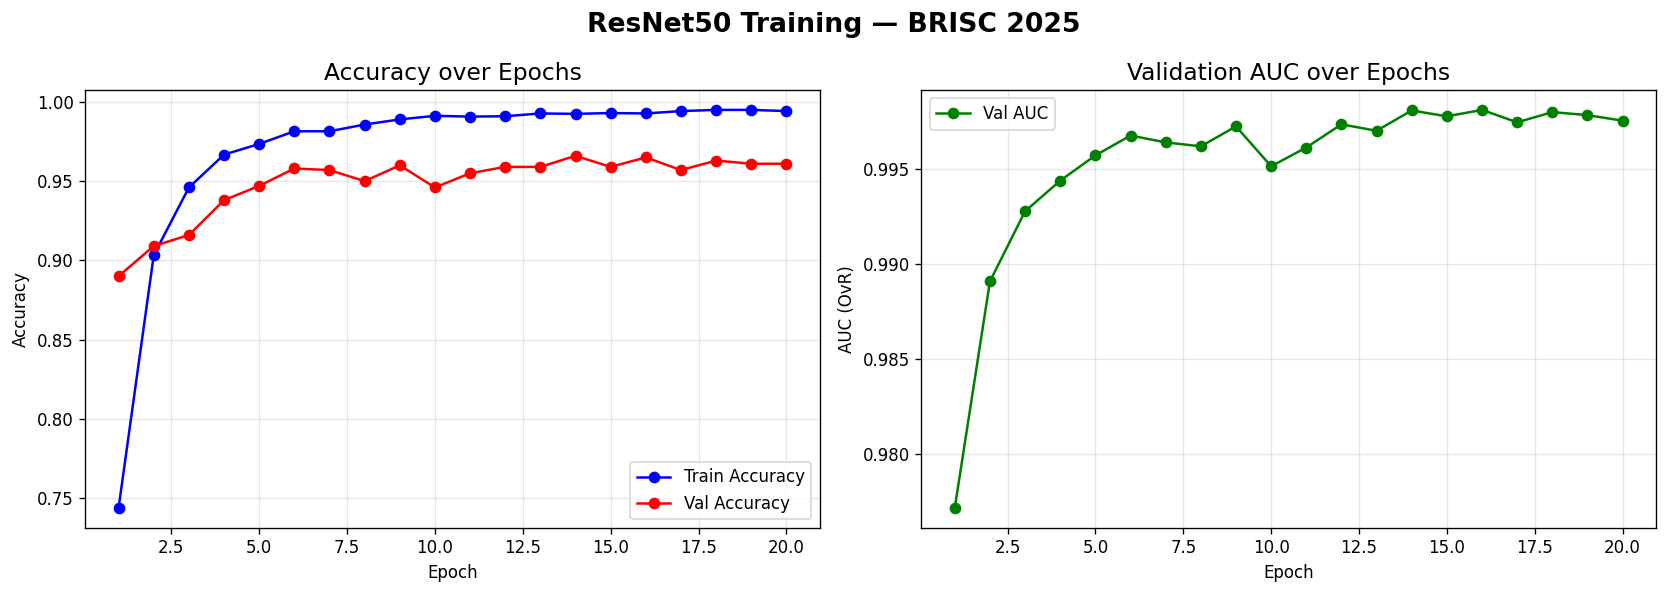

Training curves saved


In [10]:
epochs_ran = range(1, len(history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_acc"], "b-o", label="Train Accuracy")
axes[0].plot(epochs_ran, history["val_acc"],   "r-o", label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["val_auc"], "g-o", label="Val AUC")
axes[1].set_title("Validation AUC over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC (OvR)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ResNet50 Training — BRISC 2025", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), bbox_inches="tight")
plt.show()
print("Training curves saved")

Evaluating on Test Set: 100%|██████████| 32/32 [00:05<00:00,  5.52it/s]


  FINAL TEST ACCURACY : 0.9700 (97.00%)
  FINAL TEST AUC (OvR): 0.9986

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     0.9957    0.9213    0.9571       254
  meningioma     0.9579    0.9673    0.9626       306
    no_tumor     0.9589    1.0000    0.9790       140
   pituitary     0.9677    1.0000    0.9836       300

    accuracy                         0.9700      1000
   macro avg     0.9701    0.9721    0.9706      1000
weighted avg     0.9706    0.9700    0.9698      1000



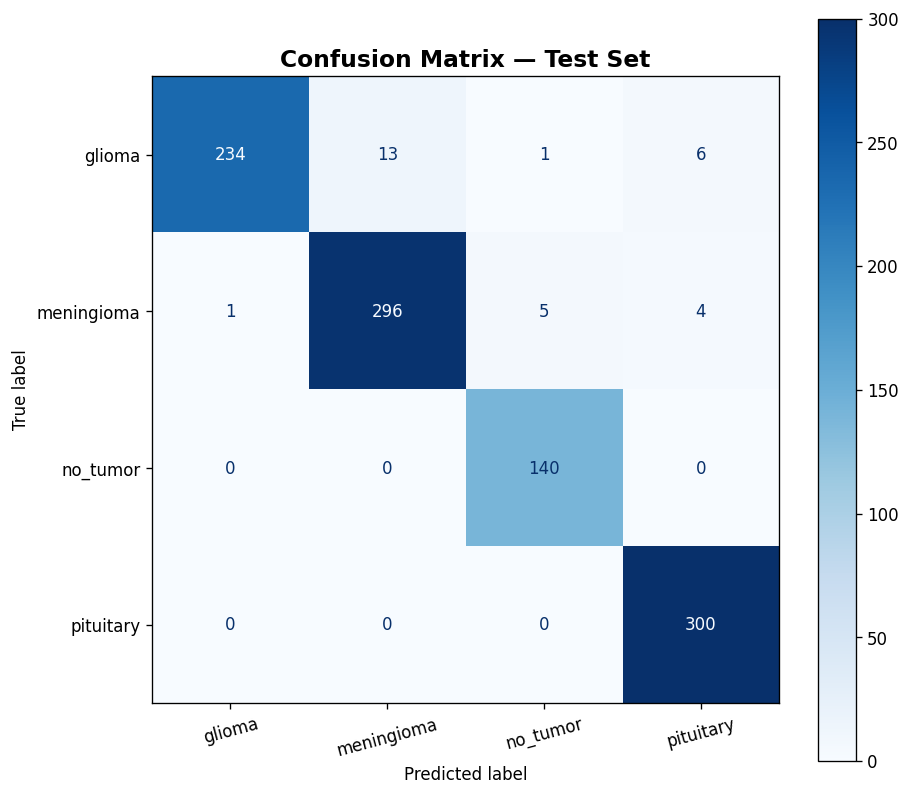

Confusion matrix saved


In [11]:
# Load best saved model
model.load_state_dict(best_state)
model.eval()

all_preds       = []
all_labels      = []
all_probs_test  = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)

        all_probs_test.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs_test = np.array(all_probs_test)
all_preds      = np.array(all_preds)
all_labels     = np.array(all_labels)

# ── METRICS ──
test_acc = np.mean(all_preds == all_labels)


try:
    test_auc = roc_auc_score(all_labels, all_probs_test, multi_class="ovr")
except Exception as e:
    test_auc = 0.0
    print(f"AUC error: {e}")

print("=" * 50)
print(f"  FINAL TEST ACCURACY : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  FINAL TEST AUC (OvR): {test_auc:.4f}")
print("=" * 50)

print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ── CONFUSION MATRIX ──
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), bbox_inches="tight")
plt.show()
print("Confusion matrix saved")

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 100.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=e6e9974ff55cdbca92696444a8933675682ac9e58e3f09ba5bd043ea87a2f2ad
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

def generate_gradcam(image_path, save_path=None):
    # Load and prepare image
    image         = cv2.imread(image_path)
    image_rgb     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    rgb_img_float = image_resized.astype(np.float32) / 255.0

    # Prepare input tensor
    input_tensor = inference_tfms(
        Image.fromarray(image_resized)
    ).unsqueeze(0).to(device)

    # Target last conv block of ResNet50
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    # Generate heatmap
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Get prediction
    with torch.no_grad():
        outputs    = model(input_tensor)
        probs      = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        pred_class = np.argmax(probs)

    # Overlay
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_resized)
    axes[0].set_title("Original MRI", fontsize=13)
    axes[0].axis("off")

    im = axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap", fontsize=13)
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(visualization)
    axes[2].set_title(
        f"Overlay\nPrediction: {class_names[pred_class]} ({probs[pred_class]:.2%})",
        fontsize=13
    )
    axes[2].axis("off")

    plt.suptitle("Grad-CAM Visualization — Brain Tumor MRI",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    print(f"\nPredicted : {class_names[pred_class]}")
    print(f"Confidence: {probs[pred_class]:.4f}")
    for name, prob in zip(class_names, probs):
        print(f"  {name:15s}: {prob:.4f}")

print("✅ Grad-CAM function ready")

✅ Grad-CAM function ready



Class: GLIOMA
Saved to /kaggle/working/outputs/gradcam_glioma.png


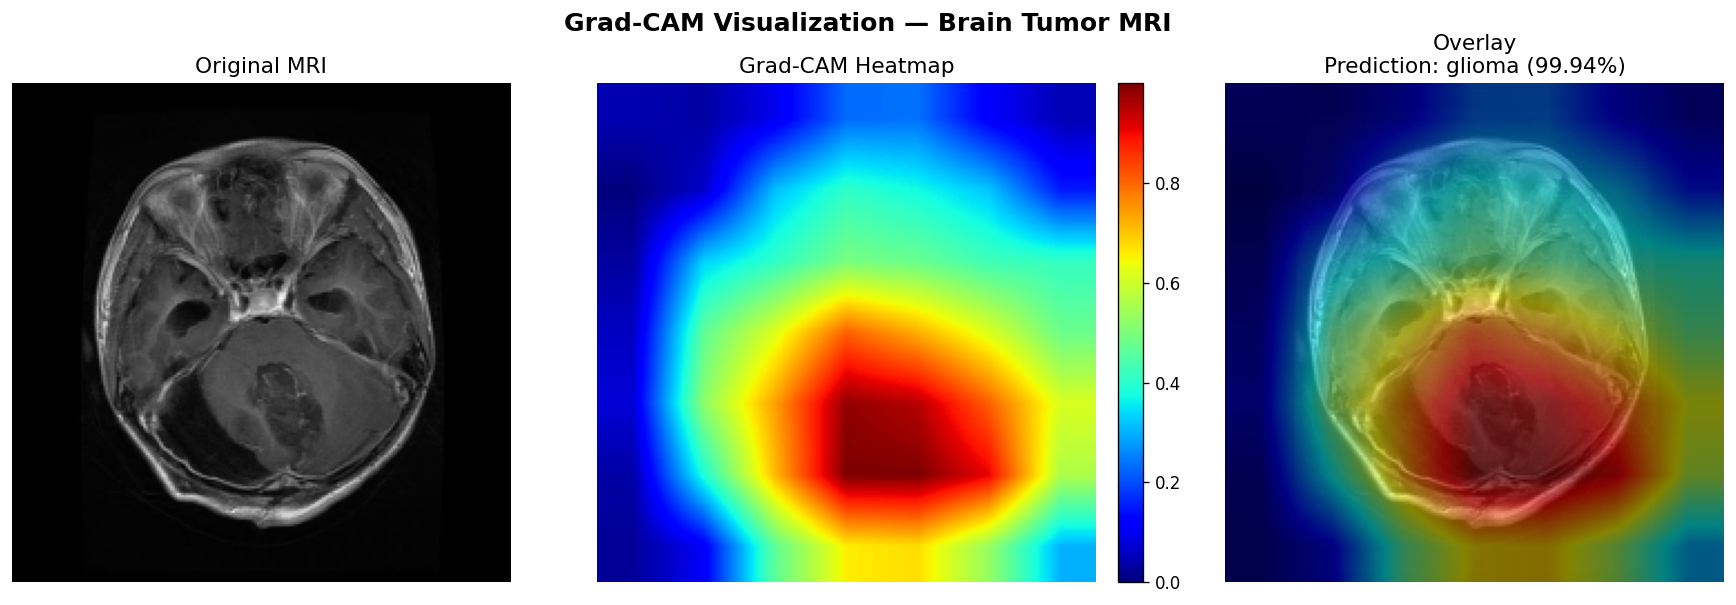


Predicted : glioma
Confidence: 0.9994
  glioma         : 0.9994
  meningioma     : 0.0003
  no_tumor       : 0.0001
  pituitary      : 0.0002

Class: MENINGIOMA
Saved to /kaggle/working/outputs/gradcam_meningioma.png


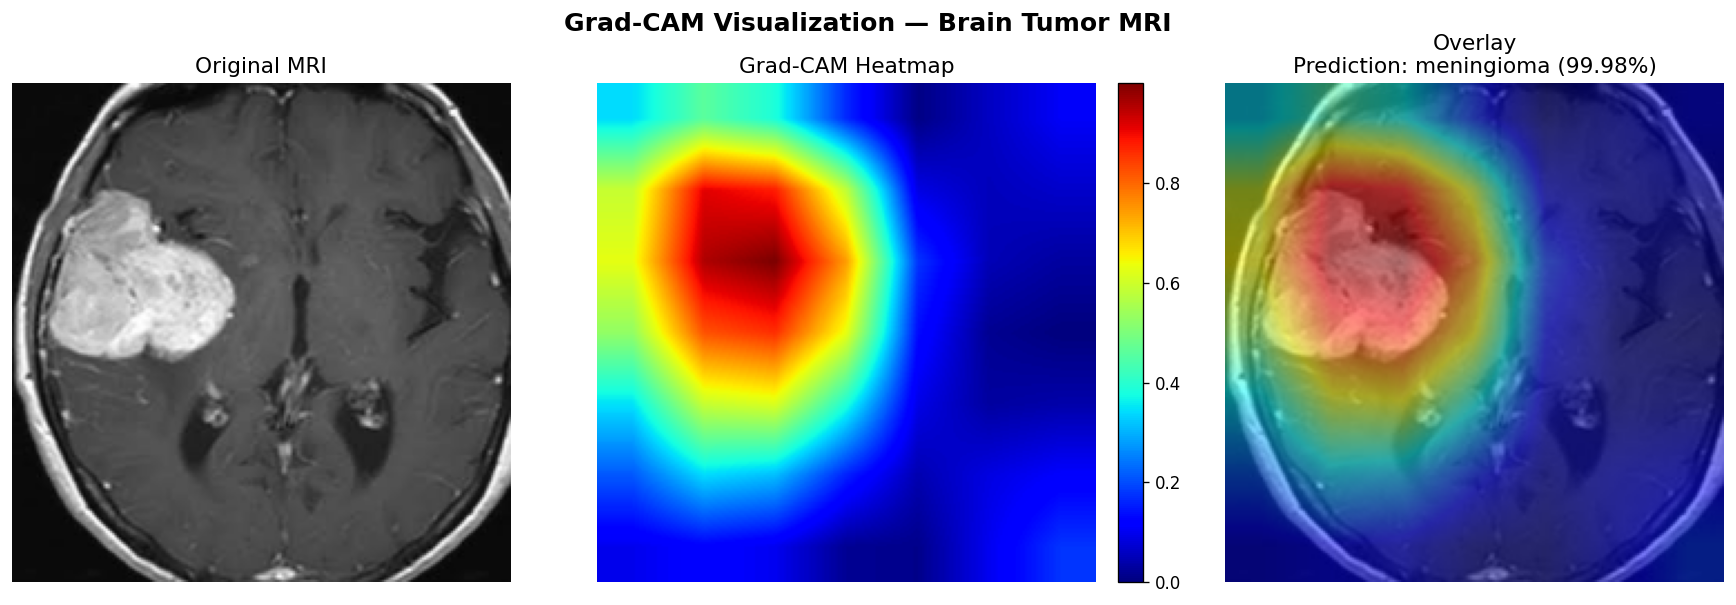


Predicted : meningioma
Confidence: 0.9998
  glioma         : 0.0000
  meningioma     : 0.9998
  no_tumor       : 0.0001
  pituitary      : 0.0001

Class: NO_TUMOR
Saved to /kaggle/working/outputs/gradcam_no_tumor.png


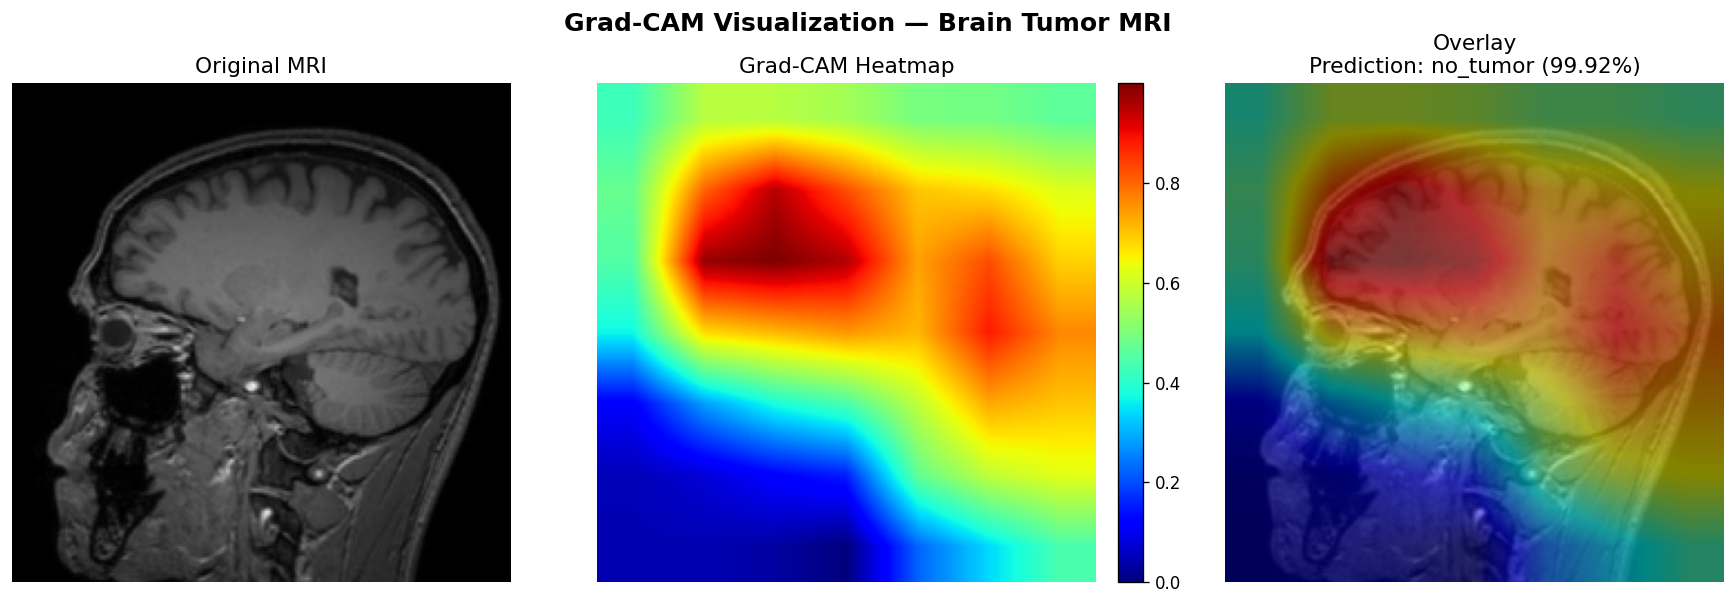


Predicted : no_tumor
Confidence: 0.9992
  glioma         : 0.0001
  meningioma     : 0.0004
  no_tumor       : 0.9992
  pituitary      : 0.0003

Class: PITUITARY
Saved to /kaggle/working/outputs/gradcam_pituitary.png


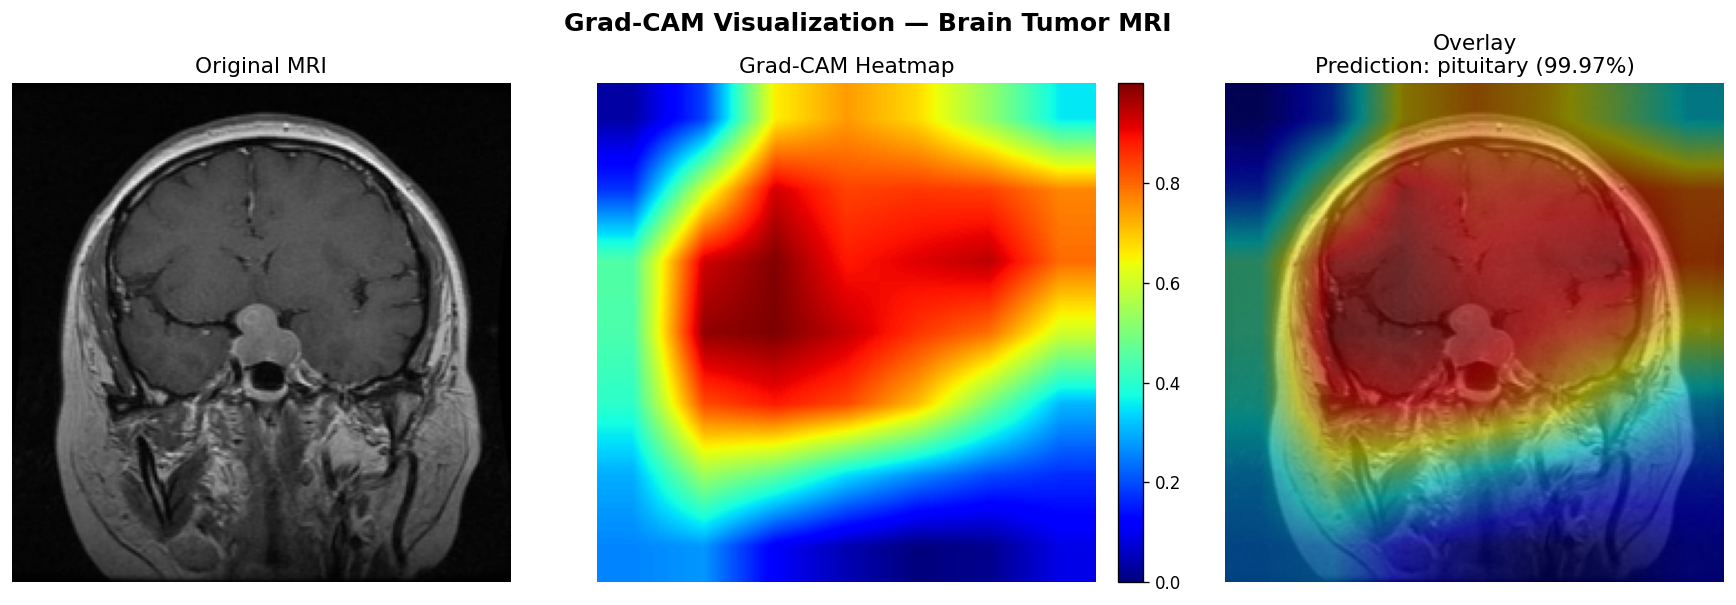


Predicted : pituitary
Confidence: 0.9997
  glioma         : 0.0000
  meningioma     : 0.0002
  no_tumor       : 0.0001
  pituitary      : 0.9997


In [15]:
import random

# Run on one image from each class for better paper figures
for class_name in class_names:
    class_dir = os.path.join(
        DATA_ROOT, "classification_task", "test", class_name
    )
    images    = os.listdir(class_dir)
    sample    = os.path.join(class_dir, random.choice(images))
    save_path = os.path.join(OUTPUT_DIR, f"gradcam_{class_name}.png")

    print(f"\n{'='*50}")
    print(f"Class: {class_name.upper()}")
    print(f"{'='*50}")
    generate_gradcam(sample, save_path=save_path)